In [1]:
## Libraries

import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
from fredapi import Fred

import statsmodels.api as sm
import matplotlib.pyplot as plt

### 1 - Initial Setup

In [2]:
# Data loading script

df = pd.read_csv(
    "../data/processed/quarterly_llp_macro.csv",
    parse_dates=["DATE"],
    index_col="DATE"
)

# Tell Pandas date is our index 
df.index = pd.to_datetime(df.index)
df = df.sort_index()

df.head()

,llp,unemployment,indpro,recession,term_spread,total_loans,llp_ratio,optimism_index,credit_spread,dcredit,nfci,dnfci
DATE,,,,,,,,,,,,
1986-01-01,4727.716,7.033333,55.355800,0.0,1.448000,1.436639e+06,0.003291,100.513167,2.452667,NaN,-0.291462,NaN
1986-04-01,5545.933,7.166667,55.021467,0.0,1.277031,1.463927e+06,0.003788,101.420000,2.672656,0.219990,-0.447154,-0.155692
1986-07-01,5254.408,6.966667,55.237800,0.0,1.621406,1.493164e+06,0.003519,99.079233,2.877031,0.204375,-0.542000,-0.094846
1986-10-01,7171.896,6.833333,55.857800,0.0,1.761935,1.528918e+06,0.004691,98.987867,2.828065,-0.048967,-0.545692,-0.003692
1987-01-01,5502.244,6.600000,56.608500,0.0,1.495738,1.577870e+06,0.003487,100.634667,2.466393,-0.361671,-0.428923,0.116769


In [3]:
# Sanity check

df.index.min(), df.index.max(), len(df)

(Timestamp('1986-01-01 00:00:00'), Timestamp('2025-10-01 00:00:00'), 160)

In [4]:
# Rename variables - d = delta

df["dllp"] = df["llp"].diff()
df["dunemp"] = df["unemployment"].diff()
df["dspread"] = df["term_spread"].diff()
df["dindpro"] = df["indpro"].diff()

### 2 - Explore Unemployment vs LLP

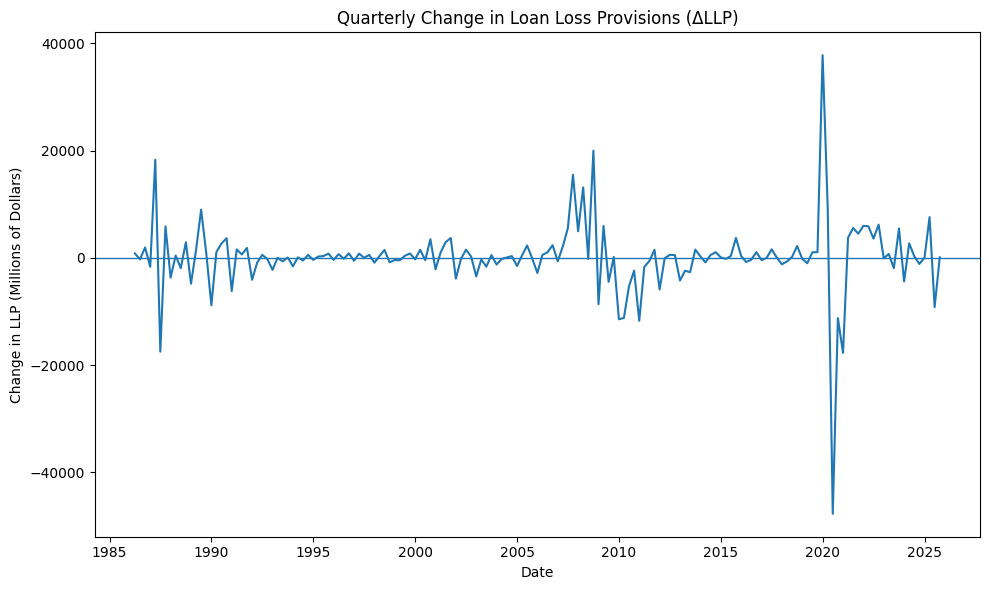

In [5]:
# Delta LLP Plot

plt.figure(figsize=(10,6))
plt.plot(df.index, df["dllp"])
plt.title("Quarterly Change in Loan Loss Provisions (ΔLLP)")
plt.ylabel("Change in LLP (Millions of Dollars)")
plt.xlabel("Date")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

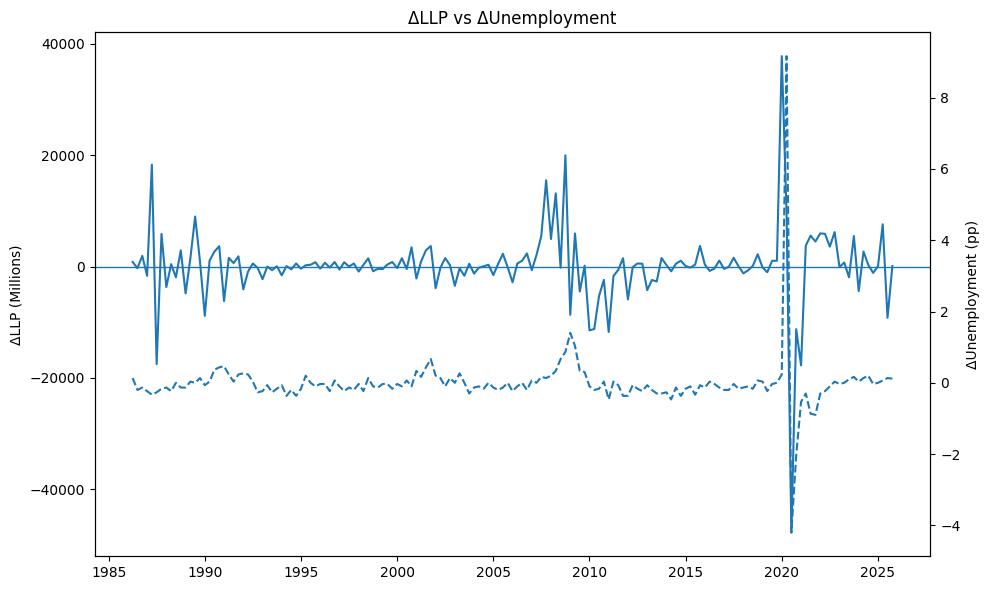

In [6]:
# Overlay Delta LLP onto Delta Unemployment

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(df.index, df["dllp"])
ax1.set_ylabel("ΔLLP (Millions)")
ax1.axhline(0, linewidth=1)

ax2 = ax1.twinx()
ax2.plot(df.index, df["dunemp"], linestyle="--")
ax2.set_ylabel("ΔUnemployment (pp)")

plt.title("ΔLLP vs ΔUnemployment")
plt.tight_layout()
plt.show()

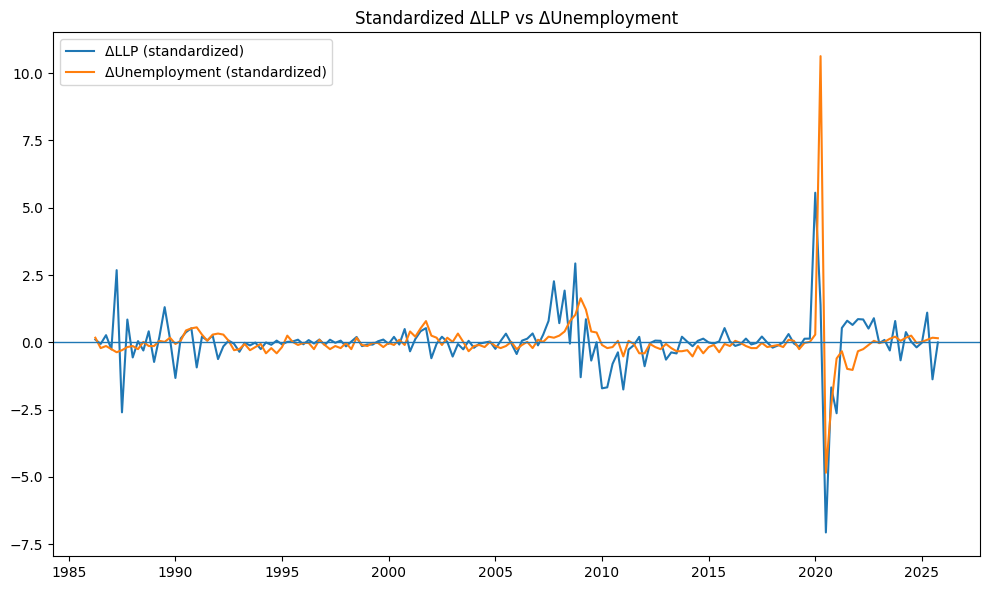

In [7]:
# Create Z Scores

df["dllp_z"] = (df["dllp"] - df["dllp"].mean()) / df["dllp"].std()
df["dunemp_z"] = (df["dunemp"] - df["dunemp"].mean()) / df["dunemp"].std()

# More readable plot

plt.figure(figsize=(10,6))
plt.plot(df.index, df["dllp_z"], label="ΔLLP (standardized)")
plt.plot(df.index, df["dunemp_z"], label="ΔUnemployment (standardized)")
plt.axhline(0, linewidth=1)
plt.legend()
plt.title("Standardized ΔLLP vs ΔUnemployment")
plt.tight_layout()
plt.show()

In [8]:
df_cc = df[["dllp", "dunemp"]].dropna()

In [9]:
# Cross-correlations for unemployment and LLP

max_lag = 8
lags = range(-max_lag, max_lag + 1)

correlations = []

for k in lags:
    if k > 0:
        corr = df_cc["dllp"].corr(df_cc["dunemp"].shift(-k))
    elif k < 0:
        corr = df_cc["dllp"].shift(k).corr(df_cc["dunemp"])
    else:
        corr = df_cc["dllp"].corr(df_cc["dunemp"])
    
    correlations.append(corr)

ccf_df = pd.DataFrame({
    "lag": list(lags),
    "correlation": correlations
})

In [10]:
peak_row = ccf_df.loc[ccf_df["correlation"].abs().idxmax()]

print("Peak lag:", peak_row["lag"])
print("Peak correlation:", peak_row["correlation"])

ccf_df.reindex(ccf_df["correlation"].abs().sort_values(ascending=False).index).head()

Peak lag: 1.0
Peak correlation: 0.4845615649972852


,lag,correlation
9,1,0.484562
7,-1,-0.382951
8,0,0.375391
5,-3,-0.246113
13,5,0.088966


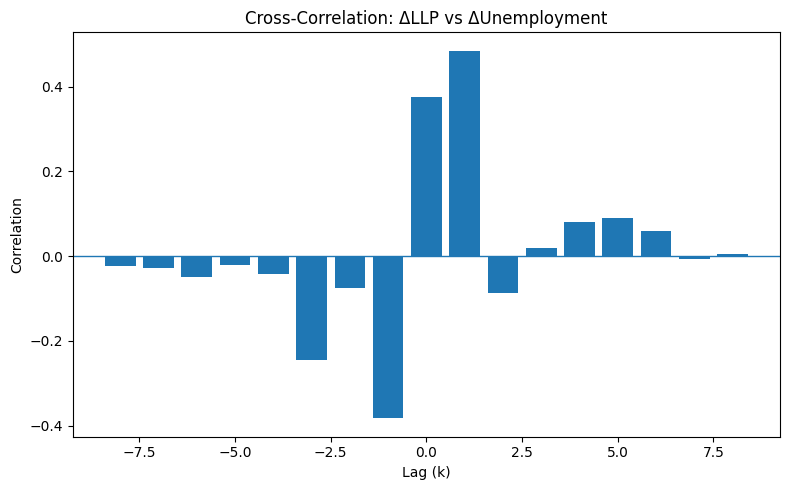

In [11]:
# Plot Lag Structure

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(ccf_df["lag"], ccf_df["correlation"])
plt.axhline(0, linewidth=1)
plt.title("Cross-Correlation: ΔLLP vs ΔUnemployment")
plt.xlabel("Lag (k)")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

In [12]:
# Identify peak lag

peak_row = ccf_df.loc[ccf_df["correlation"].abs().idxmax()]

print("Peak lag:", peak_row["lag"])
print("Peak correlation:", peak_row["correlation"])

Peak lag: 1.0
Peak correlation: 0.4845615649972852


In [13]:
# Create lags


for k in range(0, 5):
    df[f"dunemp_lag{k}"] = df["dunemp"].shift(k)

In [14]:
# Regression dataset

reg_cols = ["dllp"] + [f"dunemp_lag{k}" for k in range(0,5)]

df_reg = df[reg_cols].dropna()

In [15]:
df_reg.head()
df_reg.shape

(155, 6)

In [16]:
X = df_reg[[f"dunemp_lag{k}" for k in range(0,5)]]
X = sm.add_constant(X)

y = df_reg["dllp"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   dllp   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     16.98
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           2.87e-13
Time:                        17:25:20   Log-Likelihood:                -1553.7
No. Observations:                 155   AIC:                             3119.
Df Residuals:                     149   BIC:                             3138.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -5.1390    447.753     -0.011      

In [17]:
model_robust = sm.OLS(y, X).fit(cov_type="HC1")
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                   dllp   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     9.404
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           8.28e-08
Time:                        17:25:20   Log-Likelihood:                -1553.7
No. Observations:                 155   AIC:                             3119.
Df Residuals:                     149   BIC:                             3138.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -5.1390    459.426     -0.011      

In [18]:
sum(model_robust.params[1:])

-5326.308648203099

### 1.5 - Unemployment with the addition of total loans

In [19]:
df["dllp_ratio"] = df["llp_ratio"].diff()
df["dunemp"] = df["unemployment"].diff()

In [20]:
# create lagged unemployment

for k in range(0, 5):
    df[f"dunemp_lag{k}"] = df["dunemp"].shift(k)

In [21]:
# Regression dataset

reg_cols = ["dllp_ratio"] + [f"dunemp_lag{k}" for k in range(0,5)]

df_reg = df[reg_cols].dropna()

df_reg.shape

(155, 6)

In [22]:
# Distributed lag with robust SE

X = df_reg[[f"dunemp_lag{k}" for k in range(0,5)]]
X = sm.add_constant(X)

y = df_reg["dllp_ratio"]

model_ratio = sm.OLS(y, X).fit(cov_type="HC1")

print(model_ratio.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     5.805
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           6.29e-05
Time:                        17:25:20   Log-Likelihood:                 777.71
No. Observations:                 155   AIC:                            -1543.
Df Residuals:                     149   BIC:                            -1525.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -2.16e-05      0.000     -0.167      

In [23]:
sum(model_ratio.params[1:])


-0.00047181294603947934

In [24]:
# Reload new data

import pandas as pd
import statsmodels.api as sm

df = pd.read_csv(
    "../data/processed/quarterly_llp_macro.csv",
    parse_dates=["DATE"],
    index_col="DATE"
)

df = df.sort_index()

df.index.min(), df.index.max(), len(df)

(Timestamp('1986-01-01 00:00:00'), Timestamp('2025-10-01 00:00:00'), 160)

In [25]:
# Construct all first differences - macro signals in change form

df["dllp_ratio"] = df["llp_ratio"].diff()
df["dunemp"] = df["unemployment"].diff()
df["dindpro"] = df["indpro"].diff()
df["dspread"] = df["term_spread"].diff()
df["doptimism"] = df["optimism_index"].diff()

In [26]:
# Drop missing rows

df_diff = df[[
    "dllp_ratio",
    "dunemp",
    "dindpro",
    "dspread",
    "doptimism"
]].dropna()

In [27]:
# Check shape

df_diff.shape

(159, 5)

In [28]:
# Test Opti only

for k in range(0, 4):
    df_diff[f"doptimism_lag{k}"] = df_diff["doptimism"].shift(k)

df_opt = df_diff[["dllp_ratio"] + [f"doptimism_lag{k}" for k in range(0,4)]].dropna()

In [29]:
X = df_opt[[f"doptimism_lag{k}" for k in range(0,4)]]
X = sm.add_constant(X)
y = df_opt["dllp_ratio"]

model_opt = sm.OLS(y, X).fit(cov_type="HC1")
print(model_opt.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     1.759
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.140
Time:                        17:25:20   Log-Likelihood:                 783.12
No. Observations:                 156   AIC:                            -1556.
Df Residuals:                     151   BIC:                            -1541.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const           -2.26e-05      0.000     -0.

In [30]:
df.head()

,llp,unemployment,indpro,recession,term_spread,total_loans,llp_ratio,optimism_index,credit_spread,dcredit,nfci,dnfci,dllp_ratio,dunemp,dindpro,dspread,doptimism
DATE,,,,,,,,,,,,,,,,,
1986-01-01,4727.716,7.033333,55.355800,0.0,1.448000,1.436639e+06,0.003291,100.513167,2.452667,NaN,-0.291462,NaN,NaN,NaN,NaN,NaN,NaN
1986-04-01,5545.933,7.166667,55.021467,0.0,1.277031,1.463927e+06,0.003788,101.420000,2.672656,0.219990,-0.447154,-0.155692,0.000498,0.133333,-0.334333,-0.170969,0.906833
1986-07-01,5254.408,6.966667,55.237800,0.0,1.621406,1.493164e+06,0.003519,99.079233,2.877031,0.204375,-0.542000,-0.094846,-0.000269,-0.200000,0.216333,0.344375,-2.340767
1986-10-01,7171.896,6.833333,55.857800,0.0,1.761935,1.528918e+06,0.004691,98.987867,2.828065,-0.048967,-0.545692,-0.003692,0.001172,-0.133333,0.620000,0.140529,-0.091367
1987-01-01,5502.244,6.600000,56.608500,0.0,1.495738,1.577870e+06,0.003487,100.634667,2.466393,-0.361671,-0.428923,0.116769,-0.001204,-0.233333,0.750700,-0.266198,1.646800


## Multi-Signal distributed lag model

In [31]:
for k in range(0, 4):
    df_diff[f"dunemp_lag{k}"] = df_diff["dunemp"].shift(k)
    df_diff[f"dindpro_lag{k}"] = df_diff["dindpro"].shift(k)
    df_diff[f"dspread_lag{k}"] = df_diff["dspread"].shift(k)
    df_diff[f"doptimism_lag{k}"] = df_diff["doptimism"].shift(k)

In [32]:
# Regression dataset

lag_vars = []

for var in ["dunemp", "dindpro", "dspread", "doptimism"]:
    for k in range(0, 4):
        lag_vars.append(f"{var}_lag{k}")

df_reg = df_diff[["dllp_ratio"] + lag_vars].dropna()

In [33]:
X = df_reg[lag_vars]
X = sm.add_constant(X)

y = df_reg["dllp_ratio"]

model_multi = sm.OLS(y, X).fit(cov_type="HC1")

print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     3.384
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           4.85e-05
Time:                        17:25:20   Log-Likelihood:                 797.29
No. Observations:                 156   AIC:                            -1561.
Df Residuals:                     139   BIC:                            -1509.
Df Model:                          16                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const           4.517e-05      0.000      0.

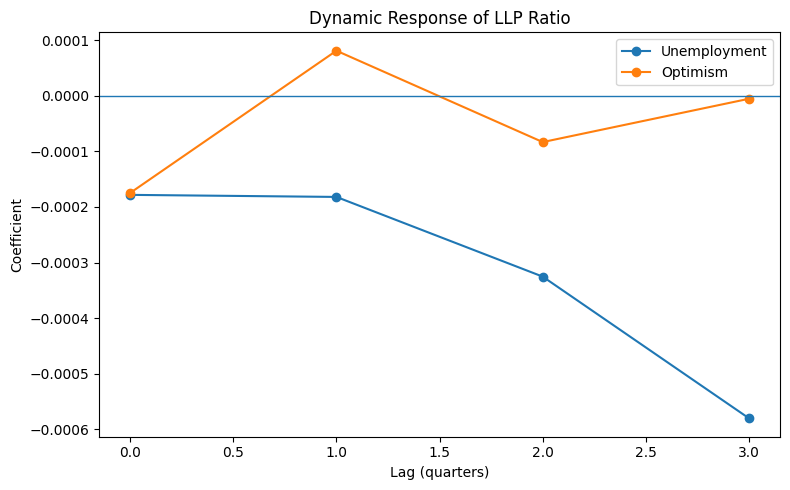

In [34]:
import matplotlib.pyplot as plt

lags = range(0, 4)

coeffs_unemp = [model_multi.params[f"dunemp_lag{k}"] for k in lags]
coeffs_opt = [model_multi.params[f"doptimism_lag{k}"] for k in lags]

plt.figure(figsize=(8,5))
plt.plot(lags, coeffs_unemp, marker='o', label="Unemployment")
plt.plot(lags, coeffs_opt, marker='o', label="Optimism")

plt.axhline(0, linewidth=1)
plt.xlabel("Lag (quarters)")
plt.ylabel("Coefficient")
plt.title("Dynamic Response of LLP Ratio")
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
# Collect lag variables

lag_vars = []
for var in ["dunemp", "dindpro", "dspread", "doptimism"]:
    for k in range(0, 4):
        lag_vars.append(f"{var}_lag{k}")

# Final regression dataset
df_reg = df_diff[["dllp_ratio"] + lag_vars].dropna()

print(df_reg.shape)

(156, 17)


In [36]:
X = df_reg[lag_vars]
X = sm.add_constant(X)

y = df_reg["dllp_ratio"]

model_multi = sm.OLS(y, X).fit(cov_type="HC1")

print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.210
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     3.384
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           4.85e-05
Time:                        17:25:20   Log-Likelihood:                 797.29
No. Observations:                 156   AIC:                            -1561.
Df Residuals:                     139   BIC:                            -1509.
Df Model:                          16                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const           4.517e-05      0.000      0.

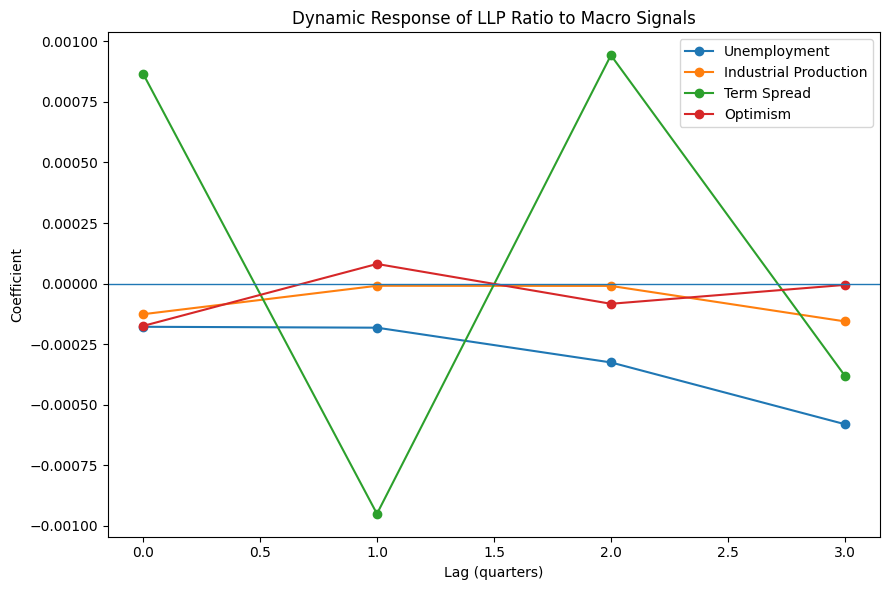

In [37]:
import matplotlib.pyplot as plt

lags = range(0, 4)

# Extract coefficients
def get_coefs(var):
    return [model_multi.params[f"{var}_lag{k}"] for k in lags]

coef_unemp = get_coefs("dunemp")
coef_indpro = get_coefs("dindpro")
coef_spread = get_coefs("dspread")
coef_optimism = get_coefs("doptimism")

# Plot
plt.figure(figsize=(9,6))

plt.plot(lags, coef_unemp, marker='o', label="Unemployment")
plt.plot(lags, coef_indpro, marker='o', label="Industrial Production")
plt.plot(lags, coef_spread, marker='o', label="Term Spread")
plt.plot(lags, coef_optimism, marker='o', label="Optimism")

plt.axhline(0, linewidth=1)
plt.xlabel("Lag (quarters)")
plt.ylabel("Coefficient")
plt.title("Dynamic Response of LLP Ratio to Macro Signals")
plt.legend()

plt.tight_layout()
plt.show()

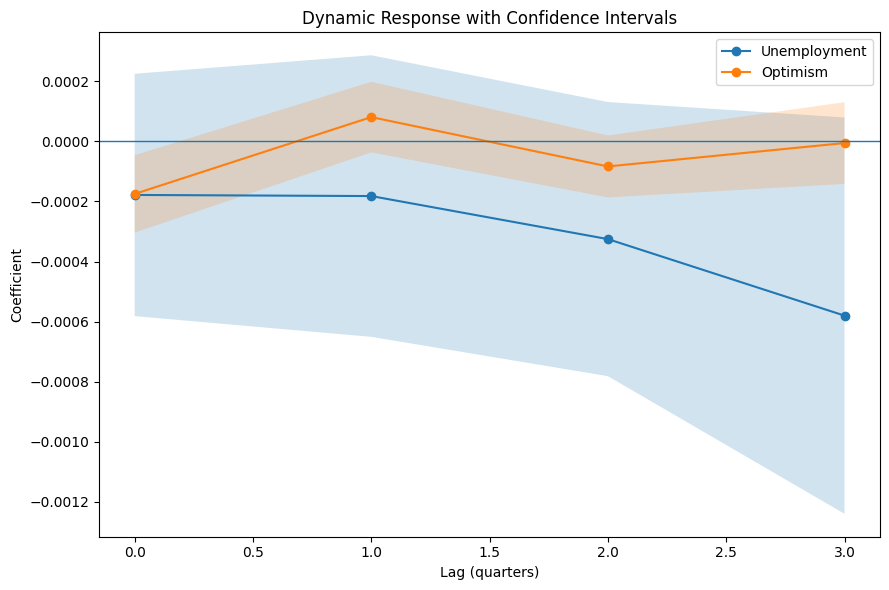

In [38]:
def get_ci(var):
    lower = []
    upper = []
    
    for k in lags:
        param = f"{var}_lag{k}"
        coef = model_multi.params[param]
        se = model_multi.bse[param]
        
        lower.append(coef - 1.96 * se)
        upper.append(coef + 1.96 * se)
    
    return lower, upper

plt.figure(figsize=(9,6))

for var, label in zip(
    ["dunemp", "doptimism"],
    ["Unemployment", "Optimism"]
):
    coef = get_coefs(var)
    lower, upper = get_ci(var)
    
    plt.plot(lags, coef, marker='o', label=label)
    plt.fill_between(lags, lower, upper, alpha=0.2)

plt.axhline(0, linewidth=1)
plt.xlabel("Lag (quarters)")
plt.ylabel("Coefficient")
plt.title("Dynamic Response with Confidence Intervals")
plt.legend()

plt.tight_layout()
plt.show()

<Axes: title={'center': 'Financial Risk Indicators'}, xlabel='DATE'>

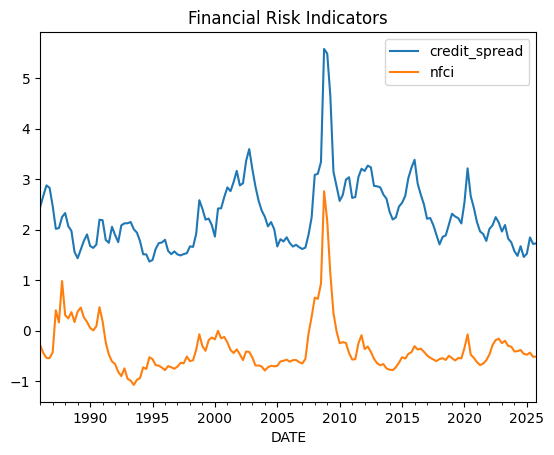

In [39]:
# Plot levels of Credit Spread and NFCI

df[["credit_spread", "nfci"]].plot(title="Financial Risk Indicators")

<Axes: title={'center': 'Changes in Financial Risk'}, xlabel='DATE'>

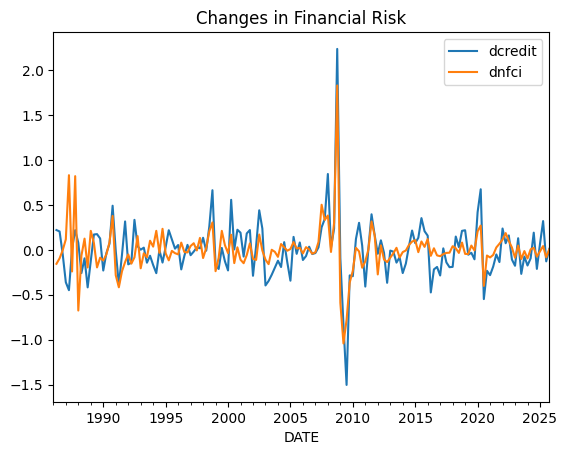

In [40]:
# Plot changes in Credit Spread and NFCI

df[["dcredit", "dnfci"]].plot(title="Changes in Financial Risk")

In [41]:
df[["dllp_ratio", "dcredit", "dnfci"]].corr()

,dllp_ratio,dcredit,dnfci
dllp_ratio,1.000000,0.172867,0.411547
dcredit,0.172867,1.000000,0.669892
dnfci,0.411547,0.669892,1.000000


In [42]:
# Build regression dataset

for k in range(0, 4):
    df[f"dcredit_lag{k}"] = df["dcredit"].shift(k)
    df[f"dnfci_lag{k}"] = df["dnfci"].shift(k)



cols_credit = ["dllp_ratio"] + [f"dcredit_lag{k}" for k in range(4)]
df_credit = df[cols_credit].dropna()

cols_nfci = ["dllp_ratio"] + [f"dnfci_lag{k}" for k in range(4)]
df_nfci = df[cols_nfci].dropna()

In [43]:
# credit spread regression

# Build dataset
cols_credit = ["dllp_ratio"] + [f"dcredit_lag{k}" for k in range(4)]
df_credit = df[cols_credit].dropna()

# Define X and y
X_credit = sm.add_constant(df_credit[[f"dcredit_lag{k}" for k in range(4)]])
y_credit = df_credit["dllp_ratio"]

# Run regression
model_credit = sm.OLS(y_credit, X_credit).fit(cov_type="HC1")

print(model_credit.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     3.986
Date:                Mon, 13 Apr 2026   Prob (F-statistic):            0.00420
Time:                        17:25:21   Log-Likelihood:                 782.30
No. Observations:                 156   AIC:                            -1555.
Df Residuals:                     151   BIC:                            -1539.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1.191e-05      0.000     -0.093   

In [44]:
# NFCI regression

# Build dataset
cols_nfci = ["dllp_ratio"] + [f"dnfci_lag{k}" for k in range(4)]
df_nfci = df[cols_nfci].dropna()

# Define X and y
X_nfci = sm.add_constant(df_nfci[[f"dnfci_lag{k}" for k in range(4)]])
y_nfci = df_nfci["dllp_ratio"]

# Run regression
model_nfci = sm.OLS(y_nfci, X_nfci).fit(cov_type="HC1")

print(model_nfci.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     4.235
Date:                Mon, 13 Apr 2026   Prob (F-statistic):            0.00281
Time:                        17:25:21   Log-Likelihood:                 799.55
No. Observations:                 156   AIC:                            -1589.
Df Residuals:                     151   BIC:                            -1574.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.036e-05      0.000     -0.174      0.8

In [45]:
# combined regression

cols_both = ["dllp_ratio"] + \
            [f"dcredit_lag{k}" for k in range(4)] + \
            [f"dnfci_lag{k}" for k in range(4)]

df_both = df[cols_both].dropna()

X_both = sm.add_constant(df_both.drop(columns=["dllp_ratio"]))
y_both = df_both["dllp_ratio"]

model_both = sm.OLS(y_both, X_both).fit(cov_type="HC1")

print(model_both.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     3.150
Date:                Mon, 13 Apr 2026   Prob (F-statistic):            0.00255
Time:                        17:25:21   Log-Likelihood:                 801.70
No. Observations:                 156   AIC:                            -1585.
Df Residuals:                     147   BIC:                            -1558.
Df Model:                           8                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1.846e-05      0.000     -0.169   

In [46]:
for k in range(1, 3):  # start with 1–2 leads only
    df[f"dcredit_lead{k}"] = df["dcredit"].shift(-k)
    df[f"dnfci_lead{k}"] = df["dnfci"].shift(-k)

In [47]:
X_lead_nfci = sm.add_constant(df[[f"dnfci_lead{k}" for k in range(1,3)]])
y = df["dllp_ratio"]

model_lead_nfci = sm.OLS(y, X_lead_nfci, missing="drop").fit(cov_type="HC1")

In [48]:
X_full = sm.add_constant(df[
    [f"dnfci_lead{k}" for k in range(1,3)] +
    [f"dnfci_lag{k}" for k in range(0,4)]
])

model_full = sm.OLS(y, X_full, missing="drop").fit(cov_type="HC1")

In [49]:
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.358
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     3.787
Date:                Mon, 13 Apr 2026   Prob (F-statistic):            0.00155
Time:                        17:25:21   Log-Likelihood:                 802.17
No. Observations:                 154   AIC:                            -1590.
Df Residuals:                     147   BIC:                            -1569.
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -6.234e-06      0.000     -0.057      

In [50]:
# ================================
# Recreate differences (if needed)
# ================================
df["dunemp"] = df["unemployment"].diff()
df["dnfci"] = df["nfci"].diff()

# ================================
# Create lags (0–3)
# ================================
for k in range(0, 4):
    df[f"dunemp_lag{k}"] = df["dunemp"].shift(k)
    df[f"dnfci_lag{k}"] = df["dnfci"].shift(k)

# ================================
# Create leads (1–2)
# ================================
for k in range(1, 3):
    df[f"dunemp_lead{k}"] = df["dunemp"].shift(-k)
    df[f"dnfci_lead{k}"] = df["dnfci"].shift(-k)


# ================================
# FULL TIMING MODEL
# ================================

# Create leads
for k in range(1, 3):
    df[f"dnfci_lead{k}"] = df["dnfci"].shift(-k)
    df[f"dunemp_lead{k}"] = df["dunemp"].shift(-k)

# Define variables
X_vars = (
    [f"dnfci_lead{k}" for k in range(1,3)] +
    [f"dnfci_lag{k}" for k in range(0,4)] +
    [f"dunemp_lead{k}" for k in range(1,3)] +
    [f"dunemp_lag{k}" for k in range(0,4)]
)

# Build dataset
df_full = df[["dllp_ratio"] + X_vars].dropna()

# Run regression
X = sm.add_constant(df_full[X_vars])
y = df_full["dllp_ratio"]

model_full = sm.OLS(y, X).fit(cov_type="HC1")

print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.446
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     20.89
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.05e-25
Time:                        17:25:21   Log-Likelihood:                 813.52
No. Observations:                 154   AIC:                            -1601.
Df Residuals:                     141   BIC:                            -1562.
Df Model:                          12                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const         4.419e-06      0.000      0.042   

In [51]:
# Regieme analysis

df["crisis"] = (
    (df.index >= "2007-01-01") & (df.index <= "2009-12-31")
).astype(int)

In [52]:
df["covid"] = (
    (df.index >= "2020-01-01") & (df.index <= "2021-12-31")
).astype(int)

In [53]:
# Crisis sample
df_crisis = df[df["crisis"] == 1].dropna()
df_normal = df[df["crisis"] == 0].dropna()

X_vars = (
    [f"dnfci_lead{k}" for k in range(1,3)] +
    [f"dnfci_lag{k}" for k in range(0,4)] +
    [f"dunemp_lead{k}" for k in range(1,3)] +
    [f"dunemp_lag{k}" for k in range(0,4)]
)

# Crisis model
X_c = sm.add_constant(df_crisis[X_vars])
y_c = df_crisis["dllp_ratio"]
model_crisis = sm.OLS(y_c, X_c).fit(cov_type="HC1")

# Normal model
X_n = sm.add_constant(df_normal[X_vars])
y_n = df_normal["dllp_ratio"]
model_normal = sm.OLS(y_n, X_n).fit(cov_type="HC1")

/Users/lukeroy/anaconda3/envs/capstone_env/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: divide by zero encountered in scalar divide
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)
/Users/lukeroy/anaconda3/envs/capstone_env/lib/python3.11/site-packages/statsmodels/regression/linear_model.py:1992: RuntimeWarning: invalid value encountered in multiply
  self.het_scale = self.nobs/(self.df_resid)*(self.wresid**2)


In [54]:
print(model_normal.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.529
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                     59.72
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.10e-46
Time:                        17:25:21   Log-Likelihood:                 759.28
No. Observations:                 142   AIC:                            -1493.
Df Residuals:                     129   BIC:                            -1454.
Df Model:                          12                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -3.739e-06      0.000     -0.034   

In [55]:
# Interactions with crisis dummy
for var in X_vars:
    df[f"{var}_crisis"] = df[var] * df["crisis"]

X_interact = sm.add_constant(
    df[X_vars + [f"{var}_crisis" for var in X_vars]]
)

y = df["dllp_ratio"]

model_interact = sm.OLS(y, X_interact, missing="drop").fit(cov_type="HC1")

In [56]:
print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                 2.006e+04
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          2.41e-206
Time:                        17:25:21   Log-Likelihood:                 829.69
No. Observations:                 154   AIC:                            -1609.
Df Residuals:                     129   BIC:                            -1533.
Df Model:                          24                                         
Covariance Type:                  HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -3.739e-06    

/Users/lukeroy/anaconda3/envs/capstone_env/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 13
  warnings.warn('covariance of constraints does not have full '


In [60]:
# Create leads (1 and 2)
for k in range(1, 3):
    df[f"dunemp_lead{k}"] = df["dunemp"].shift(-k)
    df[f"dindpro_lead{k}"] = df["dindpro"].shift(-k)
    df[f"dspread_lead{k}"] = df["dspread"].shift(-k)
    df[f"dcredit_lead{k}"] = df["dcredit"].shift(-k)
    df[f"dnfci_lead{k}"] = df["dnfci"].shift(-k)
    df[f"doptimism_lead{k}"] = df["doptimism"].shift(-k)

In [62]:
# Create lags (0–3) for all variables
for k in range(0, 4):
    df[f"dunemp_lag{k}"] = df["dunemp"].shift(k)
    df[f"dindpro_lag{k}"] = df["dindpro"].shift(k)
    df[f"dspread_lag{k}"] = df["dspread"].shift(k)
    df[f"dcredit_lag{k}"] = df["dcredit"].shift(k)
    df[f"dnfci_lag{k}"] = df["dnfci"].shift(k)
    df[f"doptimism_lag{k}"] = df["doptimism"].shift(k)

In [58]:
X_vars = (
    # Unemployment
    [f"dunemp_lead{k}" for k in range(1,3)] +
    [f"dunemp_lag{k}" for k in range(0,4)] +

    # Industrial Production
    [f"dindpro_lead{k}" for k in range(1,3)] +
    [f"dindpro_lag{k}" for k in range(0,4)] +

    # Term Spread
    [f"dspread_lead{k}" for k in range(1,3)] +
    [f"dspread_lag{k}" for k in range(0,4)] +

    # Credit Spread
    [f"dcredit_lead{k}" for k in range(1,3)] +
    [f"dcredit_lag{k}" for k in range(0,4)] +

    # NFCI
    [f"dnfci_lead{k}" for k in range(1,3)] +
    [f"dnfci_lag{k}" for k in range(0,4)] +

    # Optimism
    [f"doptimism_lead{k}" for k in range(1,3)] +
    [f"doptimism_lag{k}" for k in range(0,4)]
)

In [63]:
# Drop missing values
df_full = df[["dllp_ratio"] + X_vars].dropna()

# Define X and y
X = sm.add_constant(df_full[X_vars])
y = df_full["dllp_ratio"]

# Run regression
model_full = sm.OLS(y, X).fit(cov_type="HC1")

# Output
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:             dllp_ratio   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     6.959
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           4.78e-16
Time:                        17:26:37   Log-Likelihood:                 837.35
No. Observations:                 154   AIC:                            -1601.
Df Residuals:                     117   BIC:                            -1488.
Df Model:                          36                                         
Covariance Type:                  HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            7.673e-05   9.41e-05     